# Testes de hipóteses para a média (multidimensional)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import random
random.seed(123)

In [6]:
df = pd.read_csv('banco.csv', decimal='.', sep=',', index_col=0)
df.head()

,Sexo,Idade,CartaodeCredito,ChequeEspecial,Renda,LimiteCartaodeCredito,LimiteChequeEspecial,Devedor,SaldoDevedor
ID,,,,,,,,,
1,0,26,0,0,"2471,51","0,00","0,00","0,00","0,00"
2,1,25,1,1,"2781,90","4172,85","2781,90","0,00","0,00"
3,0,29,0,0,"2567,38","0,00","0,00","0,00","0,00"
4,1,29,1,0,"3329,50","4994,24","0,00","0,00","0,00"
5,1,19,0,1,"2074,08","0,00","2074,08","1,00","5887,33"


In [7]:
from scipy.stats import f

In [8]:
def T2Hotelling(df, mu0, n, p):
    Xbarra=df.mean()
    S = df.cov()
    S_inv = np.linalg.inv(S)
    T2Hotelling = n*np.array(Xbarra-mu0).T.dot(S_inv).dot(np.array(Xbarra-mu0))
    qf = f.ppf(0.95, p , n-p, loc=0, scale=1)
    teste = T2Hotelling > (n-1) * p / (n-p) * qf
    pvalor = 1-f.cdf(T2Hotelling/((n-1) * p / (n-p) ), p, n-p)
    print('Rejeitamos H0') if teste else print('Não rejeitamos H0')
    print('Valor da estatística', T2Hotelling)
    print('valor p', pvalor)

In [9]:
df_amostra = df.sample(100)

In [13]:
mu0 = [0.3, 30, 0.48, 0.43, 3000, 2100, 1240, 0.28, 2150]
df_amostra = df_amostra.apply(pd.to_numeric, errors='coerce')
df_amostra = df_amostra.dropna()
n=len(df_amostra)
p=len(df_amostra.columns)

T2Hotelling(df_amostra, mu0, n, p)

Não rejeitamos H0
Valor da estatística nan
valor p nan


c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [14]:
df_amostra.mean()

Sexo                    NaN
Idade                   NaN
CartaodeCredito         NaN
ChequeEspecial          NaN
Renda                   NaN
LimiteCartaodeCredito   NaN
LimiteChequeEspecial    NaN
Devedor                 NaN
SaldoDevedor            NaN
dtype: float64

### Região de confiança

In [15]:
Xbarra = df_amostra.mean()
mu0 = [0.3, 30, 0.48, 0.43, 3000, 2100, 1240, 0.28, 2150]
S_inv = np.linalg.inv(df_amostra.cov())
n = len(df_amostra)

Teste = n*np.array(Xbarra-mu0).T.dot(S_inv).dot(np.array(Xbarra-mu0)) < (n-1) * p / (n-p) * f.ppf(0.95, p , n-p, loc=0, scale=1)

print('Resultado: mu0 está na região de confiança de mu') if(Teste) else print('Resultado: mu0 não está na região de confiança de mu')

Resultado: mu0 não está na região de confiança de mu


# Testes de hipóteses para a comparação de médias em amostras independentes

### Medias amostrais

In [16]:
df_amostra[df_amostra['Sexo']==0].mean()

Sexo                    NaN
Idade                   NaN
CartaodeCredito         NaN
ChequeEspecial          NaN
Renda                   NaN
LimiteCartaodeCredito   NaN
LimiteChequeEspecial    NaN
Devedor                 NaN
SaldoDevedor            NaN
dtype: float64

In [17]:
df_amostra[df_amostra['Sexo']==1].mean()

Sexo                    NaN
Idade                   NaN
CartaodeCredito         NaN
ChequeEspecial          NaN
Renda                   NaN
LimiteCartaodeCredito   NaN
LimiteChequeEspecial    NaN
Devedor                 NaN
SaldoDevedor            NaN
dtype: float64

c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)


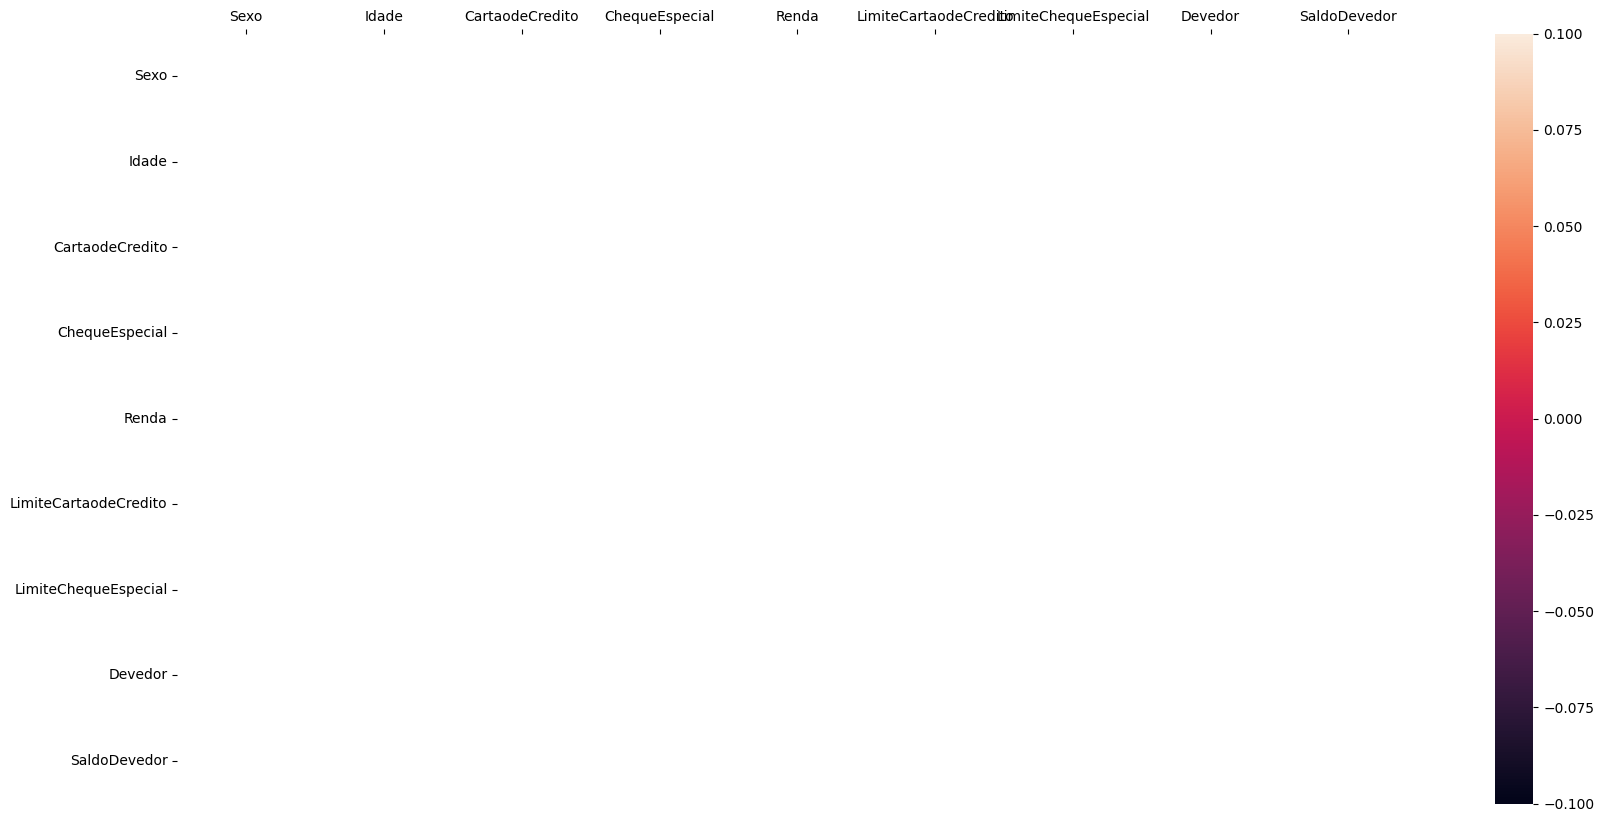

In [18]:
import seaborn as sns

corrmat =  df_amostra.corr()
corrmat

fig, ax = plt.subplots(figsize=(20,10))  
sns.heatmap(corrmat, vmax=1., square=False).xaxis.tick_top()

In [19]:
# Dados mulheres

S1 = df_amostra.iloc[:,1:8][df_amostra['Sexo']==1].cov()
n1 = len(df_amostra[df_amostra['Sexo']==1])
Xbarra1 = df_amostra[df_amostra['Sexo']==1].mean()
S1

c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,Idade,CartaodeCredito,ChequeEspecial,Renda,LimiteCartaodeCredito,LimiteChequeEspecial,Devedor
Idade,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CartaodeCredito,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChequeEspecial,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renda,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LimiteCartaodeCredito,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LimiteChequeEspecial,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Devedor,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
n1

0

In [21]:
# Dados homens

S2 = df.iloc[:,1:8][df['Sexo']==0].cov()
n2 = len(df_amostra[df_amostra['Sexo']==0])
Xbarra2 = df_amostra[df_amostra['Sexo']==0].mean()
S2

ValueError: could not convert string to float: '2471,51'

In [22]:
n2

NameError: name 'n2' is not defined

In [23]:
S_pooled = ((n1-1)*S1 + (n2-1)*S2)/(n1+n2-2)
S_pooled

NameError: name 'n2' is not defined

In [24]:
def T2Hotelling_duas_amostras(df1, df2, delta0):
    n1 = len(df1)
    n2 = len(df2)
    p = len(df1.columns)
    Xbarra1=df1.mean()
    Xbarra2=df2.mean()
    S1 = df1.cov()
    S2 = df2.cov()
    S_pooled = ((n1-1)*S1 + (n2-1)*S2)/(n1+n2-2)
    S_pooled_inv = np.linalg.inv(S_pooled)
    
    T2Hotelling_duas_amostras = np.array(Xbarra1-Xbarra2-delta0).T.dot(S_pooled_inv).dot(np.array(Xbarra1-Xbarra2-delta0)) / (n1+n2-2)
    qf = f.ppf(0.95, p , (n1+n2-2), loc=0, scale=1)
    teste = T2Hotelling_duas_amostras > (n1+n2-2) * p / (n1+n2-p-1) * qf
    pvalor = 1-f.cdf(T2Hotelling_duas_amostras/((n1+n2-2) * p / (n1+n2-p-1) ), p, (n1+n2-2))
    print('Rejeitamos H0') if teste else print('Não rejeitamos H0')
    print('Valor da estatística', T2Hotelling_duas_amostras)
    print('valor p', pvalor)

In [25]:
df1 = df_amostra.iloc[:,1:8][df_amostra['Sexo']==1]
df2 = df_amostra.iloc[:,1:8][df_amostra['Sexo']==0]

delta0 = [0,0,0,0,0,0,0]

T2Hotelling_duas_amostras(df1,df2,delta0)

Não rejeitamos H0
Valor da estatística nan
valor p nan


c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\march\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


# Testes de hipóteses para a comparação de médias em amostras correlacionadas

### Amostras pareadas

In [26]:
mean = [0, 0, 0]
mean1 = [1, 0, 0]

cov1 = [[2,1,0],[1,3,1],[0,1,4]]  
cov2 = [[0.01,0,0],[0,0.01,0],[0,0,0.01]]

X1 = np.random.multivariate_normal(mean, cov1, 50)
X2 = X1 + np.random.multivariate_normal(mean1, cov2, 50)

In [27]:
X = np.concatenate((X1,X2), axis=1)
X.shape

(50, 6)

In [28]:
df = pd.DataFrame(X)
df.head()

,0,1,2,3,4,5
0,-0.422605,0.690187,0.133490,0.645979,0.750301,0.199897
1,0.179858,0.209801,-0.702141,1.265896,0.101847,-0.698425
2,0.823051,1.583193,-0.821370,1.615430,1.650421,-0.979943
3,0.836747,1.644762,1.473795,1.703559,1.770727,1.472097
4,0.253483,-1.038775,-0.586253,1.266434,-1.010378,-0.585649


In [29]:
df.mean()

0   -0.065361
1   -0.147687
2    0.002815
3    0.941799
4   -0.148422
5    0.018682
dtype: float64

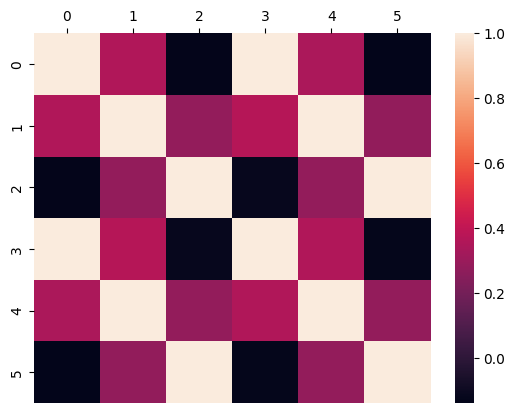

In [30]:
corrmat =  df.corr()
corrmat

sns.heatmap(corrmat, vmax=1., square=False).xaxis.tick_top()

In [31]:
df_diff =  pd.DataFrame((X1-X2))

In [32]:
df_diff.head()

,0,1,2
0,-1.068584,-0.060113,-0.066407
1,-1.086038,0.107954,-0.003716
2,-0.792379,-0.067228,0.158573
3,-0.866812,-0.125965,0.001698
4,-1.012951,-0.028397,-0.000604


In [33]:
mu0=[0,0,0]
n=len(df_diff)
p=len(df_diff.columns)
T2Hotelling(df_diff, mu0, n, p)

Rejeitamos H0
Valor da estatística 5437.858779863424
valor p 1.1102230246251565e-16
